In [1]:
PROJ_NAME = "dilithium_poly_decompose_ttest"
LABEL = "32mhzhalf"
OFFSET = 0

In [2]:
import sys
sys.path.insert(0, "../")
from host.ttest_trace_collector import TTestTraceCollector

In [3]:
trace_collector = TTestTraceCollector(proj_name=PROJ_NAME, label=LABEL, input_len=32,
                                      output_len=0, offset=OFFSET)

In [4]:
trace_collector.init_target(force=False)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [5]:
trace_collector.default_setup(40E6, 12, 36000)

In [6]:
trace_collector.build_fw()
trace_collector.program_fw()

-DDILITHIUM_MODE=3 -DSS_VER=1 -O3 -I../../../../fw/dilithium_hw -I../victims_commons -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o dilithium_poly_decompose_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc dilithium_poly_decompose_ttest.c ../../../../fw/dilithium_hw/packing.c ../../../../fw/dilithium_hw/poly.c ../../../../fw/dilithium_hw/polyvec.c ../../../../fw/dilithium_hw/randombytes.c ../../../../fw/dilithium_hw/sign.c ../../../../fw/dilithium_hw/symmetric.c ../../../../fw/dilithium_hw/reduce.c ../../../../fw/dilithium_hw/masked.c ../../../../fw/dilithium_hw/masked_sign.c ../../../../fw/dilithium_hw/masked_poly.c ../../../../fw/dilithium_hw/masked_polyvec.c ../../../../fw/dilithium_hw/masked_gadgets.c ../../../../fw/dilithium_hw/masked_packing.c ../../../../fw/dilithium_hw/masked_symmetric.c ../victims_commons/victims_commons_util.c .

../../simpleserial/simpleserial_cw305_rq.c: In function 'simpleserial_get':
../../simpleserial/simpleserial_cw305_rq.c:432:9: warning: implicit declaration of function 'memset' [-Wimplicit-function-declaration]
  432 |         memset(ascii_buf, '0', commands[cmd].len << 1);
      |         ^~~~~~
../../simpleserial/simpleserial_cw305_rq.c:6:1: note: include '<string.h>' or provide a declaration of 'memset'
    5 | #include "cw305.h"
  +++ |+#include <string.h>
    6 | 
../../simpleserial/simpleserial_cw305_rq.c:432:9: warning: incompatible implicit declaration of built-in function 'memset' [-Wbuiltin-declaration-mismatch]
  432 |         memset(ascii_buf, '0', commands[cmd].len << 1);
      |         ^~~~~~
../../simpleserial/simpleserial_cw305_rq.c:432:9: note: include '<string.h>' or provide a declaration of 'memset'


/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .init   -j .text dilithium_poly_decompose_ttest.elf dilithium_poly_decompose_ttest.inst.bin
/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .rodata -j .data dilithium_poly_decompose_ttest.elf dilithium_poly_decompose_ttest.data.bin
python3 ../../../../sdk/toolchain/rom_generator.py dilithium_poly_decompose_ttest.inst.bin dilithium_poly_decompose_ttest.inst.mem 
python3 ../../../../sdk/toolchain/rom_generator.py dilithium_poly_decompose_ttest.data.bin dilithium_poly_decompose_ttest.data.mem 
/opt/riscv/bin/riscv64-unknown-elf-size -B dilithium_poly_decompose_ttest.elf
   text	   data	    bss	    dec	    hex	filename
   5764	      0	  14596	  20360	   4f88	dilithium_poly_decompose_ttest.elf
Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin


../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin: 100%|██████████| 4.65k/4.65k [00:04<00:00, 1.11kB/s]
../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin.
Sending file: ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin


../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin: 100%|██████████| 1.07k/1.07k [00:01<00:00, 953B/s]


File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin.
Program load complete.
Serial port closed.


# PRNG=OFF

In [7]:
trace_collector.collect_traces(N=1000, prng_off=True, overwrite=True, check_output=False, dummy_inbetween_1=False)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r0_o0_rand2randnop.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r1_o0_rand2randnop.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).


In [8]:
ttest_analysis_off = trace_collector.get_analysis_obj(N=1000, prng_off=True)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r0_o0_rand2randnop.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r1_o0_rand2randnop.ets with 1000 traces.
s................: float64



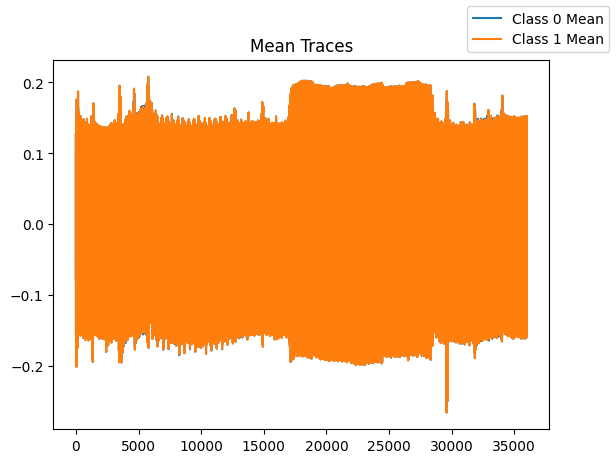

In [9]:
ttest_analysis_off.plot_means()

In [10]:
ttest_analysis_off.run_ttest()

Running T-Test:   0%|          | 0/1 [00:00<?, ?it/s]

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


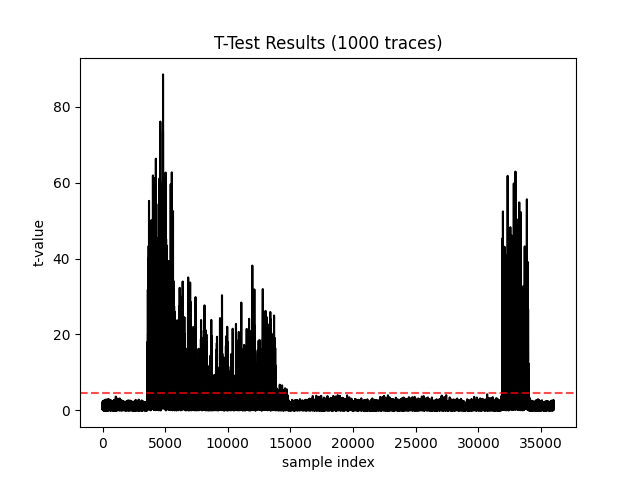

In [11]:
%matplotlib widget
ttest_analysis_off.plot_ttest()

# PRNG=ON

In [7]:
trace_collector.collect_traces(N=100000, prng_off=False, overwrite=True, check_output=False, dummy_inbetween_0=True, dummy_inbetween_1=True, rand2rand=False)

Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/dilithium_poly_decompose_ttest_N100000_prngoff0_r0_o0_32mhzhalf.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/dilithium_poly_decompose_ttest_N100000_prngoff0_r1_o0_32mhzhalf.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).


In [11]:
ttest_analysis_on = trace_collector.get_analysis_obj(N=10, prng_off=False)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r0_newx2x with 10 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r1_newx2x with 10 traces.
s................: float64



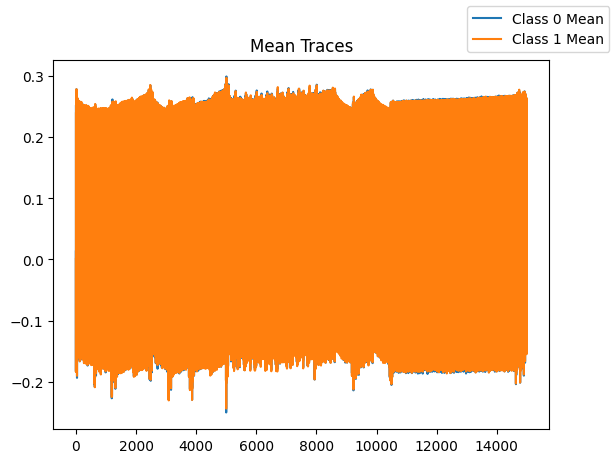

In [12]:
ttest_analysis_on.plot_means()

In [ ]:
ttest_analysis_on.run_ttest()

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


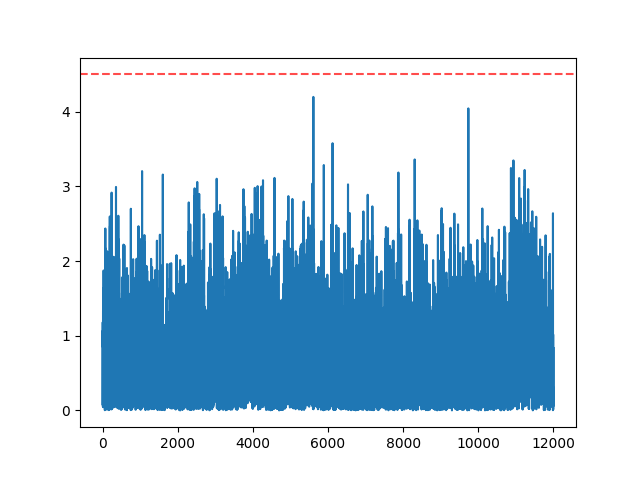

In [ ]:
ttest_analysis_on.plot_ttest(ylimit=10)